<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timesries_analysis_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00


   ADF Statistic: -9.8727
   p-value: 0.0000
   ✅ The series is stationary. Differencing (d=0) might suffice.
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16180.504, Time=5.97 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16647.544, Time=0.42 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16308.924, Time=0.44 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16200.823, Time=1.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16645.544, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=15344.665, Time=16.59 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=16075.220, Time=1.12 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=15333.279, Time=19.48 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=16002.108, Time=2.50 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=15341.290, Time=19.04 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=18.00 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=15331.279, Time=6.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=153

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- ARIMA Performance Results ---
MAE               : 1.0320
RMSE              : 1.4025
R² Score          : -0.0262
Adjusted R² Score : -0.0290


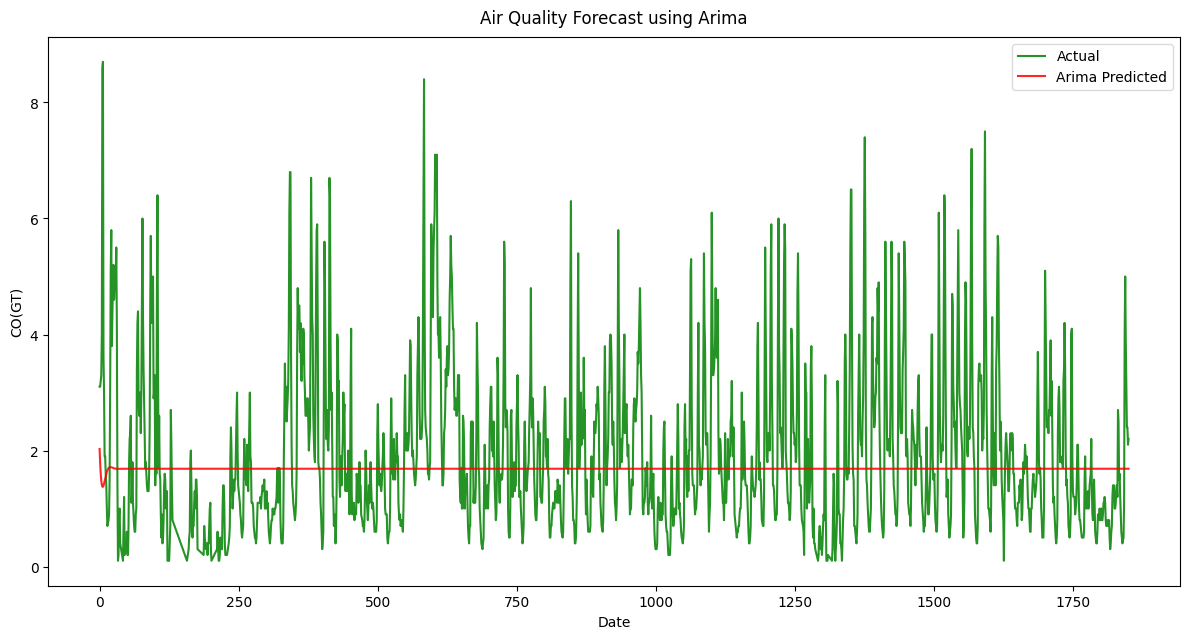

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import requests
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#importing data
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=False)
#Data preprocessing
df = df.dropna(subset=['Date', 'Time'])
df = df.iloc[:, :15]
df['Date'] = df['Date'].astype(str).str.replace('/', '-')
df['Time'] = df['Time'].astype(str).str.replace('.', ':')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')
# Set temporal index and sort chronologically
df = df.set_index('Datetime').sort_index()
# Handle UCI missing data flag (-200) by converting to NaN
df = df.replace(-200, np.nan)
# assigning column T as the target
target_col = df['CO(GT)'].copy().interpolate(method='linear')
target_col = target_col.dropna().reset_index(drop=True)

#Checking stationarity via Augmented Dickey-Fuller...
adf_result = adfuller(target_col)
print(f"   ADF Statistic: {adf_result[0]:.4f}")
print(f"   p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("   ✅ The series is stationary. Differencing (d=0) might suffice.")
else:
    print("   ⚠️ The series is non-stationary. Differencing (d>=1) is needed.")
#Train and test split
test_len = 1850
train_data = target_col.iloc[:-test_len]
test_data = target_col.iloc[-test_len:]
#Parameter setting
stepwise_model = auto_arima(
    train_data,
    start_p=1, start_q=1, max_p=3, max_q=3,
    d=None, trace=True, error_action='ignore',
    suppress_warnings=True, stepwise=True
)
#model defining and training
model = ARIMA(train_data, order=stepwise_model.order)
model_fitted = model.fit()
#Prediction as forecasting
forecast = model_fitted.forecast(steps=len(test_data))
# ACCURACY METRICS

y_true = test_data.values
y_pred = forecast.values

# MAE, RMSE, and R2
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Adjusted R2
n = len(y_true)     # Number of test data points
k = stepwise_model.order[0] + stepwise_model.order[2] # Number of predictors (AR + MA coefficients)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# ==========================================
# Evaluation Metrics results
# ==========================================
print(f"--- ARIMA Performance Results ---")
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")

## 3. GENERATE TARGET PLOT GRAPH
# ==========================================
plt.figure(figsize=(12, 6.5))
plot_data = test_data # Actual historical data
predictions = forecast # Forecasted values
x_axis = np.arange(test_len)
plt.plot(x_axis, y_true, label='Actual', color='green', linewidth=1.5, alpha=0.85)
plt.plot(x_axis, y_pred, label='Arima Predicted', color='red', linewidth=1.5,alpha=0.85)

# Structural styling adjustments to match your image
plt.title(f"Air Quality Forecast using Arima", fontsize=12, pad=10)
plt.xlabel("Date", fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d3d3d3')
plt.tight_layout()
plt.show()